# Day 10 – Model Evaluation + Cross Validation
### 20-Day ML Revision Planner | Phase: Advanced ML

**Topics covered:**
1. Classification Metrics: Confusion Matrix, Accuracy, Precision, Recall, F1, Specificity
2. ROC-AUC and PR-AUC
3. Log Loss
4. Regression Metrics: MAE, MSE, RMSE, R², Adjusted R², MAPE
5. Cross Validation: K-Fold, Stratified K-Fold, Leave-One-Out, Time Series Split
6. Critical Concept: Data Leakage and How to Prevent It
7. Metric Decision Guide (Daily Output)
8. Interview Questions
9. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold, LeaveOneOut,
                                      TimeSeriesSplit, cross_val_score, cross_validate)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score,
                              recall_score, f1_score, roc_curve, roc_auc_score, precision_recall_curve,
                              average_precision_score, log_loss, mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
np.random.seed(42)
print("Setup complete.")


Setup complete.


## 1. The Confusion Matrix & Core Classification Metrics

### What?
A **confusion matrix** breaks down predictions into four outcomes (binary case):

| | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | True Positive (TP) | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |

From these four counts, we derive:
- **Accuracy** $= \frac{TP+TN}{TP+TN+FP+FN}$ — overall fraction correct.
- **Precision** $= \frac{TP}{TP+FP}$ — "of predicted positives, how many were right?" (cost of false alarms)
- **Recall (Sensitivity)** $= \frac{TP}{TP+FN}$ — "of actual positives, how many did we catch?" (cost of missed cases)
- **Specificity** $= \frac{TN}{TN+FP}$ — "of actual negatives, how many did we correctly identify?"
- **F1-score** $= 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision}+\text{Recall}}$ — harmonic mean, balances precision and recall.

### Why?
**Accuracy is often misleading**, especially on imbalanced data (full depth on Day 15). E.g., if 95% of samples are negative, a model that *always* predicts negative gets 95% accuracy while being useless.

### How to choose?
- Prioritize **Recall** when missing a positive is costly (e.g., disease diagnosis, fraud detection).
- Prioritize **Precision** when false alarms are costly (e.g., spam filtering annoying users, unnecessary medical procedures).
- Use **F1** when you need one balanced number and both errors matter comparably.


Confusion Matrix:
 [[52  1]
 [ 1 89]]

TP=89, TN=52, FP=1, FN=1


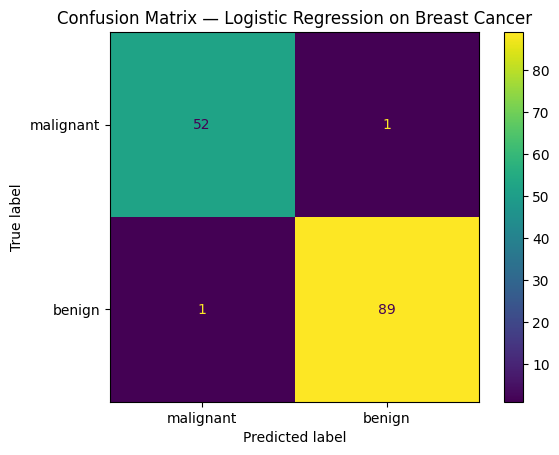

In [2]:
# Load Breast Cancer dataset and train a baseline classifier
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=5000))])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix:\n", cm)
print(f"\nTP={tp}, TN={tn}, FP={fp}, FN={fn}")

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names).plot()
plt.title("Confusion Matrix — Logistic Regression on Breast Cancer")
plt.show()


In [3]:
# Compute all metrics manually, then verify against sklearn
accuracy_manual = (tp + tn) / (tp + tn + fp + fn)
precision_manual = tp / (tp + fp)
recall_manual = tp / (tp + fn)
specificity_manual = tn / (tn + fp)
f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)

print(f"{'Metric':<15}{'Manual':>10}{'sklearn':>10}")
print(f"{'Accuracy':<15}{accuracy_manual:>10.4f}{accuracy_score(y_test, y_pred):>10.4f}")
print(f"{'Precision':<15}{precision_manual:>10.4f}{precision_score(y_test, y_pred):>10.4f}")
print(f"{'Recall':<15}{recall_manual:>10.4f}{recall_score(y_test, y_pred):>10.4f}")
print(f"{'Specificity':<15}{specificity_manual:>10.4f}{'(no direct sklearn fn)':>10}")
print(f"{'F1-score':<15}{f1_manual:>10.4f}{f1_score(y_test, y_pred):>10.4f}")


Metric             Manual   sklearn
Accuracy           0.9860    0.9860
Precision          0.9889    0.9889
Recall             0.9889    0.9889
Specificity        0.9811(no direct sklearn fn)
F1-score           0.9889    0.9889


## 2. ROC-AUC and PR-AUC

### What?
- **ROC curve (Receiver Operating Characteristic)**: plots **True Positive Rate (Recall)** vs. **False Positive Rate** ($FPR = \frac{FP}{FP+TN}$) across all classification thresholds.
- **ROC-AUC**: the Area Under the ROC Curve — probability that the model ranks a random positive sample higher than a random negative sample. Ranges 0.5 (random) to 1.0 (perfect).
- **Precision-Recall (PR) curve**: plots Precision vs. Recall across thresholds.
- **PR-AUC (Average Precision)**: area under the PR curve.

### Why?
- **ROC-AUC** is popular but can be **overly optimistic on imbalanced datasets** — because FPR uses the (often large) negative class in its denominator, it can look good even when precision is poor.
- **PR-AUC** is more informative when the **positive class is rare** (imbalanced data — full depth on Day 15), since it focuses entirely on the performance regarding the positive class.

### How?
Both curves are traced by varying the classification threshold from 0 to 1 and recomputing the relevant rates at each point — no single fixed threshold (like 0.5) is assumed.


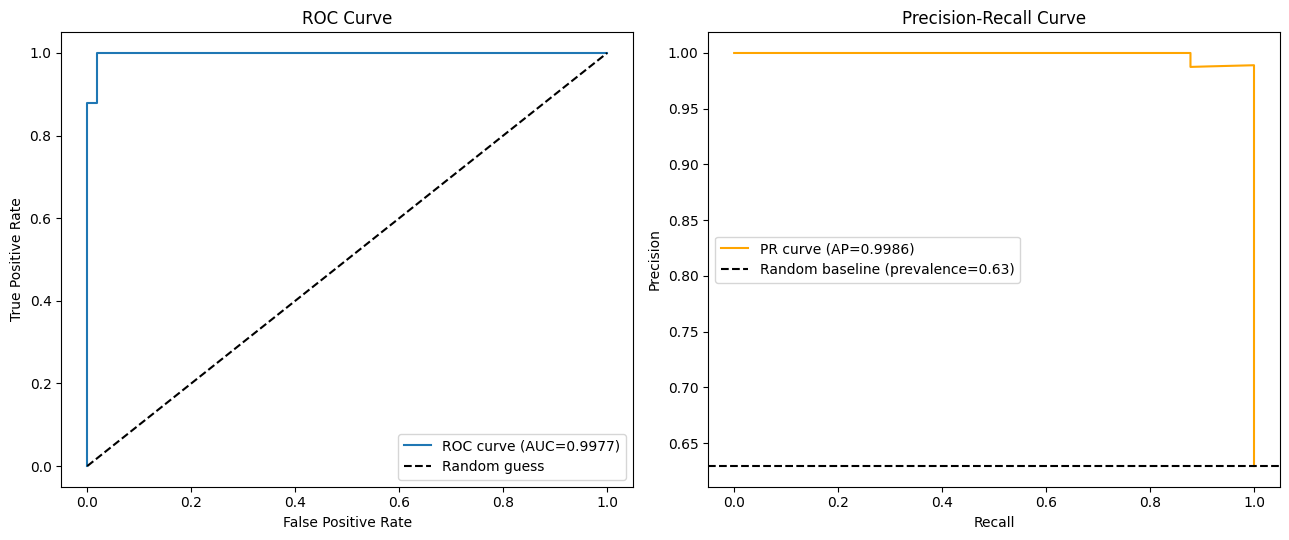

ROC-AUC: 0.9977
PR-AUC (Average Precision): 0.9986


In [4]:
# Plot ROC curve and PR curve side by side
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].plot(fpr, tpr, label=f"ROC curve (AUC={roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], 'k--', label="Random guess")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].plot(recall_vals, precision_vals, label=f"PR curve (AP={pr_auc:.4f})", color='orange')
baseline = y_test.mean()
axes[1].axhline(baseline, color='k', linestyle='--', label=f"Random baseline (prevalence={baseline:.2f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")


In [5]:
# Demonstrate why ROC-AUC can look overly optimistic on imbalanced data (simulation)
np.random.seed(7)
n_neg, n_pos = 950, 50  # 95% negative, 5% positive -- imbalanced
y_imbalanced = np.array([0]*n_neg + [1]*n_pos)
# A "mediocre" classifier: scores are only weakly informative
scores_imbalanced = np.concatenate([
    np.random.normal(0.3, 0.2, n_neg),
    np.random.normal(0.5, 0.2, n_pos)
])
scores_imbalanced = np.clip(scores_imbalanced, 0, 1)

roc_auc_imb = roc_auc_score(y_imbalanced, scores_imbalanced)
pr_auc_imb = average_precision_score(y_imbalanced, scores_imbalanced)

print(f"On a 95%/5% imbalanced dataset with a MEDIOCRE classifier:")
print(f"  ROC-AUC = {roc_auc_imb:.4f}  <-- looks reasonably good")
print(f"  PR-AUC  = {pr_auc_imb:.4f}  <-- reveals the model is much weaker at finding the rare positive class")
print("\n--> This gap is exactly why PR-AUC is preferred for rare-event detection (fraud, disease, etc.)")
print("    -- covered in full depth on Day 15 (Imbalanced Learning).")


On a 95%/5% imbalanced dataset with a MEDIOCRE classifier:
  ROC-AUC = 0.8404  <-- looks reasonably good
  PR-AUC  = 0.3108  <-- reveals the model is much weaker at finding the rare positive class

--> This gap is exactly why PR-AUC is preferred for rare-event detection (fraud, disease, etc.)
    -- covered in full depth on Day 15 (Imbalanced Learning).


## 3. Log Loss (Recap + Evaluation Framing)

### What?
Recall from Day 6: **Log Loss** penalizes predicted probabilities based on how far they are from the true label, not just whether the final class prediction was right or wrong.

$$\text{Log Loss} = -\frac{1}{m}\sum_i \left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right]$$

### Why (as an evaluation metric)?
Unlike accuracy/precision/recall (which only look at the final thresholded class), log loss evaluates the **quality of the predicted probabilities themselves** — a model that's "right but not confident" or "wrong and overconfident" gets penalized differently than accuracy alone would reveal. This matters when calibrated probabilities are important (e.g., risk scoring).

### How?
Lower log loss = better-calibrated, more confident-when-correct predictions. A model that outputs $\hat{p}=0.5$ for everything (maximally uncertain) gets a log loss of $\ln(2) \approx 0.693$.


In [6]:
# Compute log loss for our model and compare against a "maximally uncertain" baseline
model_log_loss = log_loss(y_test, y_prob)
uncertain_baseline_log_loss = log_loss(y_test, np.full_like(y_prob, 0.5))

print(f"Our model's log loss:           {model_log_loss:.4f}")
print(f"Always-predict-0.5 baseline:     {uncertain_baseline_log_loss:.4f}  (= ln(2) = {np.log(2):.4f})")
print("\n--> Lower is better. Our confident, well-calibrated model achieves a much lower log loss")
print("    than a baseline that expresses no confidence at all.")


Our model's log loss:           0.0679
Always-predict-0.5 baseline:     0.6931  (= ln(2) = 0.6931)

--> Lower is better. Our confident, well-calibrated model achieves a much lower log loss
    than a baseline that expresses no confidence at all.


## 4. Regression Metrics: MAE, MSE, RMSE, R², Adjusted R², MAPE

### What? (MAE, MSE, RMSE, R² recap from Day 5)
- **MAE**: average absolute error (robust to outliers, same units as target).
- **MSE**: average squared error (penalizes large errors heavily).
- **RMSE**: $\sqrt{\text{MSE}}$ (same units as target).
- **R²**: proportion of variance explained.
- **Adjusted R²**: R² penalized for the **number of features**, preventing the false impression that adding more features always improves fit:
  $$R^2_{adj} = 1 - (1-R^2)\frac{n-1}{n-p-1}$$
  where $n$ = number of samples, $p$ = number of features.
- **MAPE (Mean Absolute Percentage Error)**: average absolute error as a **percentage** of the actual value — scale-independent, easy to communicate to stakeholders.
  $$\text{MAPE} = \frac{1}{m}\sum_i \left|\frac{y_i - \hat{y}_i}{y_i}\right| \times 100\%$$

### Why?
- Plain **R² always increases (or stays the same)** when you add more features, even useless ones — **Adjusted R²** corrects for this, making it better for comparing models with different numbers of features.
- **MAPE** is intuitive ("our forecast is off by 8% on average") but **breaks down when actual values are near/at zero** (division by ~0).

### How?
Always report multiple metrics together, and choose based on what "cost" or "communication" story matters most for the specific business/scientific context.


In [7]:
# Regression metrics demo on the California Housing dataset (with synthetic fallback)
try:
    housing = fetch_california_housing(as_frame=True)
    house_df = housing.frame
except Exception:
    np.random.seed(30)
    n = 2000
    house_df = pd.DataFrame({
        'MedInc': np.random.gamma(5, 1.5, n),
        'HouseAge': np.random.uniform(1, 52, n),
        'AveRooms': np.random.normal(5.5, 1.2, n),
        'Population': np.random.exponential(1200, n),
    })
    house_df['MedHouseVal'] = (0.4*house_df['MedInc'] - 0.01*house_df['HouseAge'] +
                                0.05*house_df['AveRooms'] + np.random.normal(0, 0.5, n)).clip(lower=0.3)

X_house = house_df.drop(columns=['MedHouseVal'])
y_house = house_df['MedHouseVal']
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_house, y_house, test_size=0.25, random_state=42)

reg = LinearRegression().fit(X_train_h, y_train_h)
y_pred_h = reg.predict(X_test_h)

mae = mean_absolute_error(y_test_h, y_pred_h)
mse = mean_squared_error(y_test_h, y_pred_h)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_h, y_pred_h)
mape = mean_absolute_percentage_error(y_test_h, y_pred_h)

n_samples = len(y_test_h)
n_features = X_test_h.shape[1]
adj_r2 = 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)

print(f"MAE:         {mae:.4f}")
print(f"MSE:         {mse:.4f}")
print(f"RMSE:        {rmse:.4f}")
print(f"R2:          {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")
print(f"MAPE:        {mape:.2%}")


/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


MAE:         0.4001
MSE:         0.2506
RMSE:        0.5006
R2:          0.8691
Adjusted R2: 0.8681
MAPE:        19.24%


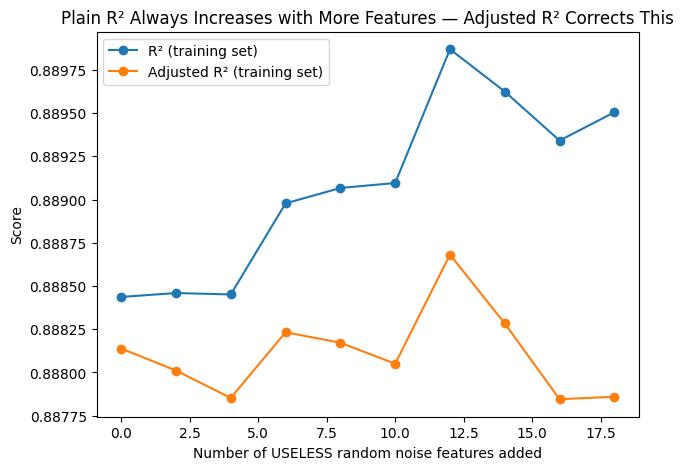

In [8]:
# Demonstrate WHY plain R2 always increases with more features (even noise features!) -- motivating Adjusted R2
np.random.seed(8)
r2_scores, adj_r2_scores = [], []
n_noise_features_range = range(0, 20, 2)

X_base = X_train_h.copy().reset_index(drop=True)
y_base = y_train_h.reset_index(drop=True)

for n_noise in n_noise_features_range:
    X_with_noise = X_base.copy()
    for i in range(n_noise):
        X_with_noise[f'noise_{i}'] = np.random.randn(len(X_with_noise))

    reg_noise = LinearRegression().fit(X_with_noise, y_base)
    preds_noise = reg_noise.predict(X_with_noise)
    r2_n = r2_score(y_base, preds_noise)
    p = X_with_noise.shape[1]
    n = len(y_base)
    adj_r2_n = 1 - (1 - r2_n) * (n - 1) / (n - p - 1)

    r2_scores.append(r2_n)
    adj_r2_scores.append(adj_r2_n)

plt.figure(figsize=(7, 5))
plt.plot(list(n_noise_features_range), r2_scores, marker='o', label="R² (training set)")
plt.plot(list(n_noise_features_range), adj_r2_scores, marker='o', label="Adjusted R² (training set)")
plt.xlabel("Number of USELESS random noise features added")
plt.ylabel("Score")
plt.title("Plain R² Always Increases with More Features — Adjusted R² Corrects This")
plt.legend()
plt.show()


## 5. Cross Validation: K-Fold, Stratified K-Fold, Leave-One-Out, Time Series Split

### What?
**Cross-validation (CV)** gives a more robust estimate of model performance than a single train/test split, by repeatedly splitting the data and averaging results.

- **K-Fold CV**: split data into $K$ equal parts ("folds"); train on $K-1$ folds, validate on the remaining fold; repeat $K$ times, rotating which fold is held out; average the $K$ scores.
- **Stratified K-Fold**: like K-Fold, but preserves the **class proportion** in each fold — essential for classification, especially with imbalanced classes (recall Day 4's `stratify=y`).
- **Leave-One-Out CV (LOOCV)**: the extreme case where $K = $ number of samples — each fold holds out just **one** sample. Very thorough but computationally expensive; mainly used for very small datasets.
- **Time Series Split**: respects **temporal order** — training folds always precede validation folds in time, never shuffling (critical to avoid look-ahead bias in forecasting — foreshadowing Day 17).

### Why?
A single train/test split gives a performance estimate that depends heavily on *which* samples happened to land in the test set — this can be noisy, especially for small datasets. CV averages over multiple splits, giving both a more reliable **mean** performance estimate and a **variance** estimate (how much performance fluctuates across folds).

### How to choose?
| Method | Use when |
|---|---|
| K-Fold | General-purpose default for regression or well-balanced classification |
| Stratified K-Fold | Classification, especially with class imbalance |
| Leave-One-Out | Very small datasets where every sample counts |
| Time Series Split | Any temporally ordered data (never shuffle!) |


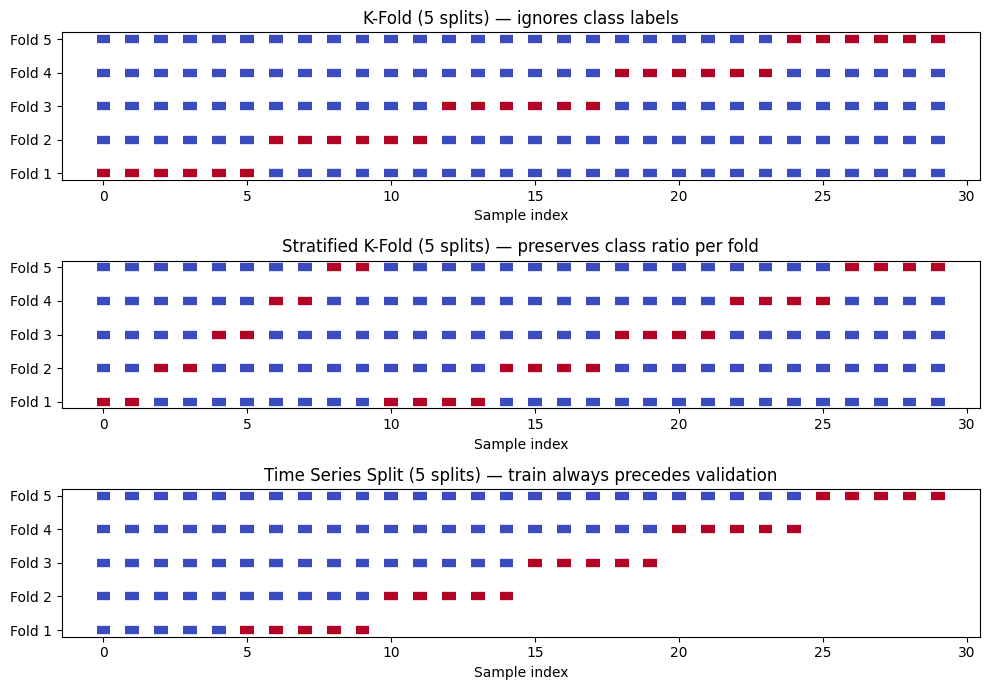

(Blue = training fold, Red = validation fold, for each row/fold)


In [9]:
# Visualize how K-Fold, Stratified K-Fold, and Time Series Split partition data differently
fig, axes = plt.subplots(3, 1, figsize=(10, 7))

n_points = 30
y_toy_cv = np.array([0]*10 + [1]*20)  # imbalanced-ish toy labels to show stratification effect

def plot_cv_indices(cv, X_len, y_labels, ax, title):
    for i, (train_idx, val_idx) in enumerate(cv.split(np.zeros(X_len), y_labels)):
        indices = np.full(X_len, np.nan)
        indices[train_idx] = 0
        indices[val_idx] = 1
        ax.scatter(range(X_len), [i] * X_len, c=indices, cmap='coolwarm', marker='_', s=100, lw=6)
    ax.set_title(title)
    ax.set_yticks(range(cv.get_n_splits()))
    ax.set_yticklabels([f"Fold {i+1}" for i in range(cv.get_n_splits())])
    ax.set_xlabel("Sample index")

plot_cv_indices(KFold(n_splits=5), n_points, y_toy_cv, axes[0], "K-Fold (5 splits) — ignores class labels")
plot_cv_indices(StratifiedKFold(n_splits=5), n_points, y_toy_cv, axes[1], "Stratified K-Fold (5 splits) — preserves class ratio per fold")
plot_cv_indices(TimeSeriesSplit(n_splits=5), n_points, y_toy_cv, axes[2], "Time Series Split (5 splits) — train always precedes validation")

plt.tight_layout()
plt.show()
print("(Blue = training fold, Red = validation fold, for each row/fold)")


In [10]:
# K-Fold vs Stratified K-Fold: verify class balance is preserved
X_cv = X_train.reset_index(drop=True)
y_cv = y_train.reset_index(drop=True)

print("Overall class balance:", y_cv.value_counts(normalize=True).to_dict())

print("\nK-Fold (NOT stratified) — class balance per fold:")
kf = KFold(n_splits=5, shuffle=True, random_state=1)
for i, (train_idx, val_idx) in enumerate(kf.split(X_cv)):
    print(f"  Fold {i+1} validation set: {y_cv.iloc[val_idx].value_counts(normalize=True).round(3).to_dict()}")

print("\nStratified K-Fold — class balance per fold:")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
for i, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
    print(f"  Fold {i+1} validation set: {y_cv.iloc[val_idx].value_counts(normalize=True).round(3).to_dict()}")


Overall class balance: {1: 0.6267605633802817, 0: 0.3732394366197183}

K-Fold (NOT stratified) — class balance per fold:
  Fold 1 validation set: {1: 0.616, 0: 0.384}
  Fold 2 validation set: {1: 0.659, 0: 0.341}
  Fold 3 validation set: {1: 0.624, 0: 0.376}
  Fold 4 validation set: {1: 0.612, 0: 0.388}
  Fold 5 validation set: {1: 0.624, 0: 0.376}

Stratified K-Fold — class balance per fold:
  Fold 1 validation set: {1: 0.628, 0: 0.372}
  Fold 2 validation set: {1: 0.624, 0: 0.376}
  Fold 3 validation set: {1: 0.624, 0: 0.376}
  Fold 4 validation set: {1: 0.624, 0: 0.376}
  Fold 5 validation set: {1: 0.635, 0: 0.365}


In [11]:
# Run full cross-validation with cross_val_score / cross_validate, using multiple metrics
cv_pipeline = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=5000))])

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = cross_validate(cv_pipeline, X, y, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                             scoring=scoring)

print("5-Fold Stratified Cross-Validation Results:")
for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"  {metric:>10}: mean={scores.mean():.4f}, std={scores.std():.4f}, per-fold={np.round(scores, 3)}")

print("\n--> Reporting mean +/- std gives a much more honest picture of expected real-world")
print("    performance than a single train/test split number.")


5-Fold Stratified Cross-Validation Results:
    accuracy: mean=0.9737, std=0.0166, per-fold=[0.974 0.947 0.965 0.991 0.991]
   precision: mean=0.9683, std=0.0290, per-fold=[0.986 0.922 0.947 1.    0.986]
      recall: mean=0.9916, std=0.0112, per-fold=[0.972 1.    1.    0.986 1.   ]
          f1: mean=0.9794, std=0.0127, per-fold=[0.979 0.959 0.973 0.993 0.993]
     roc_auc: mean=0.9953, std=0.0053, per-fold=[0.995 0.998 0.985 1.    0.999]

--> Reporting mean +/- std gives a much more honest picture of expected real-world
    performance than a single train/test split number.


In [12]:
# Leave-One-Out CV demo on a SMALL subset (LOOCV is expensive -- O(n) model fits!)
X_small = X_train.iloc[:60].reset_index(drop=True)
y_small = y_train.iloc[:60].reset_index(drop=True)

loo = LeaveOneOut()
print(f"Leave-One-Out CV will train {loo.get_n_splits(X_small)} separate models (one per sample)...")

loo_scores = cross_val_score(cv_pipeline, X_small, y_small, cv=loo)
print(f"LOOCV mean accuracy: {loo_scores.mean():.4f}")
print(f"LOOCV score distribution: {np.bincount(loo_scores.astype(int))} "
      f"(count of 0=wrong, 1=correct predictions across all {len(loo_scores)} folds)")
print("\n--> LOOCV gives an almost unbiased estimate but is very expensive and provides only")
print("    two possible outcomes per fold, which is why K-Fold (K=5 or 10) is preferred in practice.")


Leave-One-Out CV will train 60 separate models (one per sample)...


LOOCV mean accuracy: 0.9500
LOOCV score distribution: [ 3 57] (count of 0=wrong, 1=correct predictions across all 60 folds)

--> LOOCV gives an almost unbiased estimate but is very expensive and provides only
    two possible outcomes per fold, which is why K-Fold (K=5 or 10) is preferred in practice.


## 6. Critical Concept: Data Leakage and How to Prevent It

### What?
**Data leakage** occurs when information from outside the training dataset (often, indirectly, from the test/validation set) is used to create the model, leading to **overly optimistic** performance estimates that **won't hold up in production**.

### Why?
Leakage is one of the most common and damaging mistakes in real-world ML — models can look excellent in evaluation but fail immediately once deployed, because the "shortcut" information they leveraged isn't available at real prediction time.

### Common sources of leakage
1. **Preprocessing fit on full data**: fitting scalers/imputers/encoders (Day 4) on the entire dataset before splitting, so test-set statistics leak into training.
2. **Target leakage**: including a feature that is only known *after* the target is determined (e.g., using "days_until_payment" to predict "will_default", when that field is only populated once the outcome is already known).
3. **Duplicate/near-duplicate rows** split across train and test (recall Day 4's duplicate-handling).
4. **Temporal leakage**: using future information to predict the past (e.g., shuffling time-series data instead of using Time Series Split).
5. **Group leakage**: e.g., multiple rows from the same patient/customer appearing in both train and test — the model can "memorize" that entity rather than learning generalizable patterns.

### How to prevent it?
- **Always split first**, then fit any preprocessing exclusively on the training fold (recall Day 4's `Pipeline`/`ColumnTransformer` — this is EXACTLY why they matter).
- Carefully audit each feature: "would I actually have this information at prediction time, in production?"
- Use **Time Series Split** for temporal data — never shuffle.
- Use **Group K-Fold** when multiple rows belong to the same entity, to keep each entity entirely within one fold.


In [13]:
# Concrete demonstration: leakage from fitting a scaler on the FULL dataset vs TRAIN only
# (recap + reinforcement of Day 4's leakage debugging exercise, now framed via cross-validation)

# WRONG approach: fit scaler on all of X, then cross-validate (each fold's "test" already influenced the scaler)
scaler_leaky = StandardScaler().fit(X)   # fit on FULL dataset -- LEAKAGE
X_scaled_leaky = scaler_leaky.transform(X)
leaky_scores = cross_val_score(LogisticRegression(max_iter=5000), X_scaled_leaky, y, cv=5)

# CORRECT approach: scaler is refit inside each fold via Pipeline (no leakage)
correct_pipeline = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=5000))])
correct_scores = cross_val_score(correct_pipeline, X, y, cv=5)

print(f"LEAKY approach (scaler fit on full data before CV):  mean accuracy = {leaky_scores.mean():.4f}")
print(f"CORRECT approach (scaler refit inside each CV fold): mean accuracy = {correct_scores.mean():.4f}")
print("\n--> The difference may be small on this clean, well-behaved dataset, but on smaller or")
print("    noisier datasets, leakage can inflate reported performance substantially. The Pipeline")
print("    approach is ALWAYS safe -- it refits preprocessing fresh within each fold automatically.")


LEAKY approach (scaler fit on full data before CV):  mean accuracy = 0.9807
CORRECT approach (scaler refit inside each CV fold): mean accuracy = 0.9807

--> The difference may be small on this clean, well-behaved dataset, but on smaller or
    noisier datasets, leakage can inflate reported performance substantially. The Pipeline
    approach is ALWAYS safe -- it refits preprocessing fresh within each fold automatically.


## 7. Metric Decision Guide — "Which Metric Should I Use and Why?" (Daily Output)

| Situation | Recommended Metric | Why |
|---|---|---|
| Balanced classes, general purpose | Accuracy | Simple, intuitive, valid when classes are roughly balanced |
| Imbalanced classes | Precision, Recall, F1, PR-AUC | Accuracy is misleading; PR-AUC/F1 focus on the minority (often more important) class |
| False positives are costly (e.g., spam→important email) | Precision | Minimizes wrongly-flagged cases |
| False negatives are costly (e.g., disease, fraud) | Recall | Minimizes missed true cases |
| Need one balanced number | F1-score | Harmonic mean balances precision & recall |
| Need to compare models across ALL thresholds | ROC-AUC (balanced data) or PR-AUC (imbalanced data) | Threshold-independent view of ranking quality |
| Predicted probabilities/calibration matter | Log Loss | Penalizes overconfident wrong predictions, not just final class |
| Regression, outliers present, want interpretable units | MAE | Robust to outliers, same units as target |
| Regression, large errors should be penalized more | RMSE (or MSE) | Squaring amplifies large errors |
| Regression, communicating to non-technical stakeholders | MAPE | Easy "off by X%" interpretation (careful near zero values) |
| Regression, comparing models with different feature counts | Adjusted R² | Corrects R²'s bias toward more features |
| Estimating real-world generalization performance | K-Fold / Stratified K-Fold CV | More robust than a single train/test split |
| Time-ordered data (forecasting) | Time Series Split | Prevents look-ahead/temporal leakage |


## 8. Interview Questions — Practice Aloud (Close Your Notes!)

1. **Why can accuracy be a misleading metric, and what would you use instead?**
   *Hint: imbalanced classes — a trivial "always predict majority class" model can get high accuracy while being useless; use precision/recall/F1/PR-AUC instead.*

2. **Explain the difference between ROC-AUC and PR-AUC, and when you'd prefer one over the other.**
   *Hint: ROC-AUC can look optimistic on imbalanced data because FPR's denominator includes the large negative class; PR-AUC focuses on the positive class's performance.*

3. **What is data leakage, and give two concrete examples.**
   *Hint: any situation where test-set/future information influences training — e.g., fitting a scaler on the full dataset, or including a feature only known after the outcome occurs.*

4. **Why do we use K-Fold cross-validation instead of a single train/test split?**
   *Hint: more robust and less noisy performance estimate; also gives a sense of variance/stability across different data subsets.*

5. **Why is Stratified K-Fold preferred over plain K-Fold for classification?**
   *Hint: preserves class proportions in each fold, preventing folds with wildly different (or missing) class representation, especially critical for imbalanced datasets.*

6. **Why shouldn't you shuffle data when doing cross-validation on a time series?**
   *Hint: would leak future information into training folds (look-ahead bias) — must respect temporal order (Time Series Split).*

7. **(Bonus) What's the difference between R² and Adjusted R², and why does it matter?**
   *Hint: plain R² can only increase (or stay flat) as more features are added, even useless ones; Adjusted R² penalizes for feature count, giving a fairer model comparison.*


## 9. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] Draw a confusion matrix from memory and derive accuracy, precision, recall, specificity, and F1 from it.
- [ ] Explain the difference between ROC-AUC and PR-AUC, and when each is more informative.
- [ ] Explain log loss as an evaluation metric and why it differs from accuracy-based metrics.
- [ ] List all 6 regression metrics covered (MAE, MSE, RMSE, R², Adjusted R², MAPE) and when to use each.
- [ ] Explain K-Fold, Stratified K-Fold, Leave-One-Out, and Time Series Split, and when to use each.
- [ ] Define data leakage and list at least 3 common sources of it.
- [ ] Explain how `Pipeline` prevents leakage during cross-validation (tying back to Day 4).
- [ ] Use the metric decision guide to justify a metric choice for a novel scenario on the spot.

### 📌 Daily Output (per the planner)
A **Metric Decision Guide** ("Which metric should I use and why?") — produced in Section 7 above — mapping common ML situations to the right evaluation metric and the reasoning behind each choice, backed by hands-on confusion matrix, ROC/PR curve, regression metric, and cross-validation code in this notebook.

Close this notebook and re-derive the metric decision guide from memory, situation by situation — that's the real test of Day 10 mastery.
